In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# Download the UCI Phishing Dataset
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00327/Training%20Dataset.arff" -O phishing_data.arff

# Convert ARFF format to a pandas DataFrame
from scipy.io import arff

data, meta = arff.loadarff('phishing_data.arff')
df = pd.DataFrame(data)

# Decode byte strings
df = df.applymap(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

print("✅ Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

✅ Dataset loaded!
Rows: 11055, Columns: 31


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


=== Class Distribution ===
Result
1     6157
-1    4898
Name: count, dtype: int64


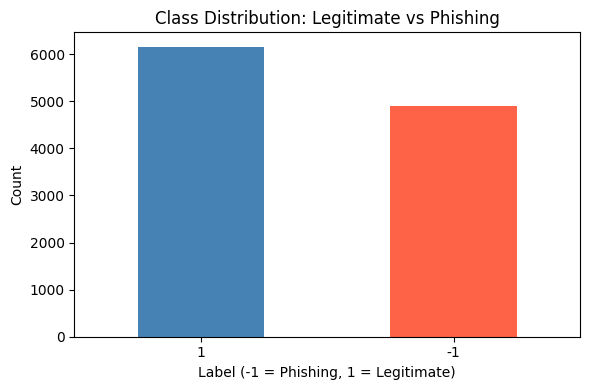

✅ EDA complete


In [3]:
# Check class distribution
print("=== Class Distribution ===")
print(df['Result'].value_counts())

# Plot class distribution bar chart
plt.figure(figsize=(6,4))
df['Result'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution: Legitimate vs Phishing')
plt.xlabel('Label (-1 = Phishing, 1 = Legitimate)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print("✅ EDA complete")

In [4]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Fill any missing with median
df.fillna(df.median(), inplace=True)

# Separate features (X) and label (y)
X = df.drop('Result', axis=1)
y = df['Result']

print("Feature shape:", X.shape)
print("Label counts:")
print(y.value_counts())
print("✅ Data cleaning complete")

Missing values: 0
Feature shape: (11055, 30)
Label counts:
Result
 1    6157
-1    4898
Name: count, dtype: int64
✅ Data cleaning complete


In [5]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples:  {X_train.shape[0]}")
print(f"Testing samples:   {X_test.shape[0]}")
print(f"Features per sample: {X_train.shape[1]}")
print("✅ Split and scaling complete")

Training samples:  8844
Testing samples:   2211
Features per sample: 30
✅ Split and scaling complete


In [6]:
# Train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("✅ Random Forest model trained!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features used: {rf_model.n_features_in_}")

✅ Random Forest model trained!
Number of trees: 100
Number of features used: 30


In [7]:
# 5-fold cross-validation
cv_scores = cross_val_score(
    rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy'
)

print("=== Cross-Validation Results ===")
print(f"Score fold 1: {cv_scores[0]*100:.2f}%")
print(f"Score fold 2: {cv_scores[1]*100:.2f}%")
print(f"Score fold 3: {cv_scores[2]*100:.2f}%")
print(f"Score fold 4: {cv_scores[3]*100:.2f}%")
print(f"Score fold 5: {cv_scores[4]*100:.2f}%")
print(f"----------------------------------")
print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation: {cv_scores.std()*100:.2f}%")
print("✅ Cross-validation complete")

=== Cross-Validation Results ===
Score fold 1: 97.51%
Score fold 2: 96.66%
Score fold 3: 96.16%
Score fold 4: 96.27%
Score fold 5: 97.45%
----------------------------------
Mean Accuracy: 96.81%
Std Deviation: 0.57%
✅ Cross-validation complete


In [8]:
# Predict on test set
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Model Performance Metrics ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print("=== Full Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Phishing (-1)', 'Legitimate (1)']))
print("✅ Metrics complete")

=== Model Performance Metrics ===
Accuracy:  97.65%
Precision: 0.9765
Recall:    0.9765
F1-Score:  0.9765
ROC-AUC:   0.9977

=== Full Classification Report ===
                precision    recall  f1-score   support

 Phishing (-1)       0.98      0.97      0.97       980
Legitimate (1)       0.97      0.98      0.98      1231

      accuracy                           0.98      2211
     macro avg       0.98      0.98      0.98      2211
  weighted avg       0.98      0.98      0.98      2211

✅ Metrics complete


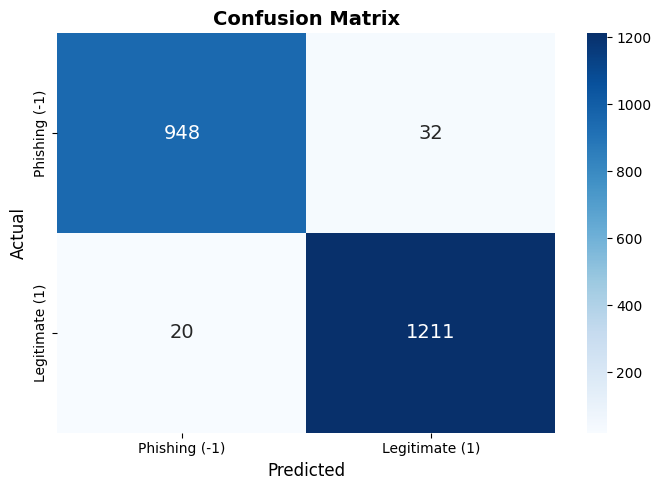

✅ Confusion matrix saved


In [9]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing (-1)', 'Legitimate (1)'],
            yticklabels=['Phishing (-1)', 'Legitimate (1)'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved")

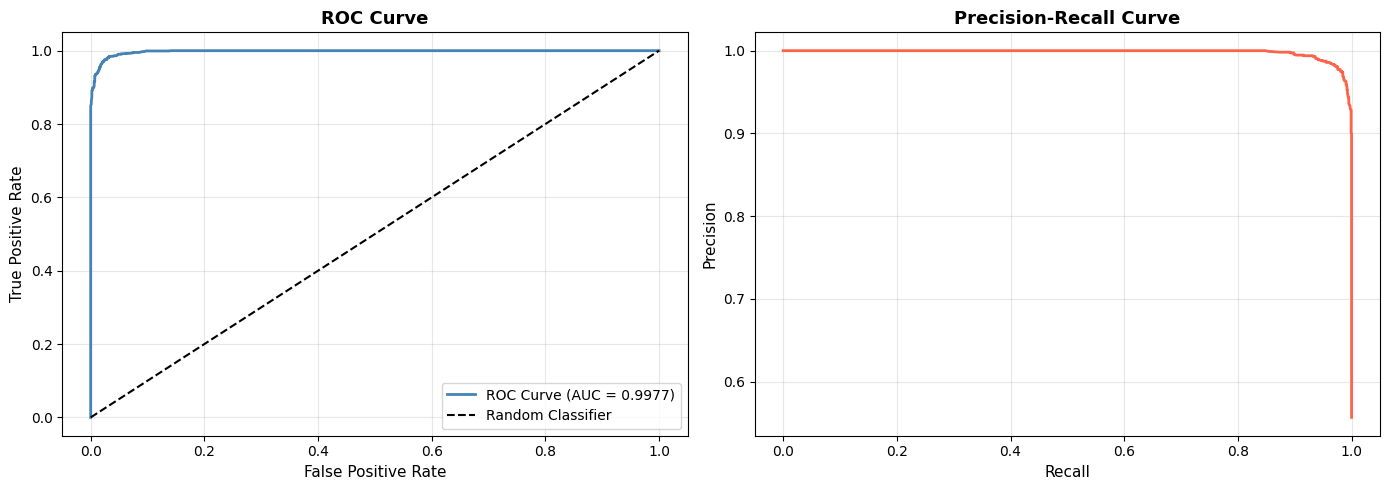

✅ ROC and PR curves saved


In [10]:
# Plot ROC Curve and PR Curve side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
ax1.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
ax1.plot([0,1],[0,1],'k--', label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- PR Curve ---
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
ax2.plot(recall_vals, precision_vals, color='tomato', lw=2)
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()
print("✅ ROC and PR curves saved")

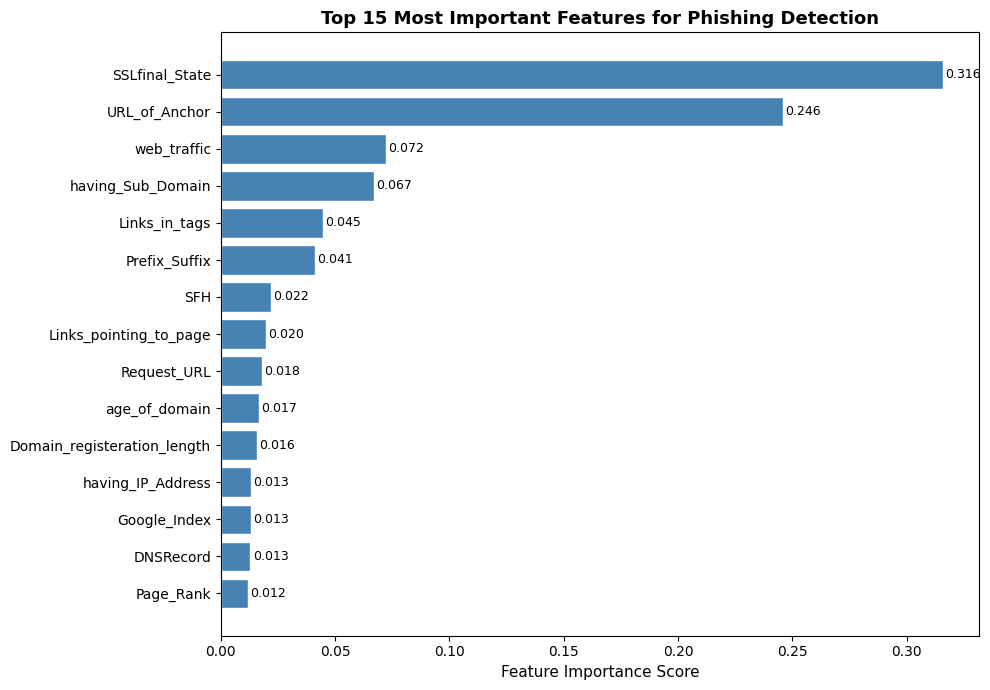

✅ Feature importance graph saved


In [11]:
# Feature Importance Graph
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
bars = plt.barh(feature_importances.index,
                feature_importances.values,
                color='steelblue', edgecolor='white')

# Add value labels on each bar
for bar, val in zip(bars, feature_importances.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.title('Top 15 Most Important Features for Phishing Detection',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance graph saved")

In [12]:
def predict_url(url):
    """Predict if a URL is phishing or legitimate"""
    import re

    # Extract basic features from the URL
    def extract_features(url):
        features = [-1] * 30  # default all features to -1

        # Feature 1: having_IP_Address
        features[0] = 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else -1
        # Feature 2: URL_Length
        features[1] = 1 if len(url) < 54 else (0 if len(url) <= 75 else -1)
        # Feature 3: @ symbol
        features[5] = 1 if '@' in url else -1
        # Feature 4: double slash redirect
        features[6] = 1 if url.rfind('//') > 7 else -1
        # Feature 5: prefix/suffix dash in domain
        domain = url.split('/')[2] if '/' in url else url
        features[7] = -1 if '-' in domain else 1
        # Feature 6: HTTPS
        features[9] = 1 if url.startswith('https') else -1

        return features

    features = extract_features(url)
    features_scaled = scaler.transform([features])
    prediction = rf_model.predict(features_scaled)[0]
    confidence = rf_model.predict_proba(features_scaled)[0].max() * 100

    print(f"\n🔍 URL: {url}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    if prediction == -1:
        print(f"🚨 RESULT:     PHISHING WEBSITE DETECTED")
    else:
        print(f"✅ RESULT:     LEGITIMATE WEBSITE")
    print(f"📊 Confidence: {confidence:.1f}%")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Test with example URLs
predict_url("http://192.168.1.1/secure/login-paypal.html")
predict_url("https://www.google.com")
predict_url("http://paypal-secure-verify.com/signin@account")
predict_url("https://www.bbc.co.uk/news")


🔍 URL: http://192.168.1.1/secure/login-paypal.html
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 RESULT:     PHISHING WEBSITE DETECTED
📊 Confidence: 85.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 URL: https://www.google.com
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 RESULT:     PHISHING WEBSITE DETECTED
📊 Confidence: 83.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 URL: http://paypal-secure-verify.com/signin@account
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 RESULT:     PHISHING WEBSITE DETECTED
📊 Confidence: 68.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 URL: https://www.bbc.co.uk/news
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 RESULT:     PHISHING WEBSITE DETECTED
📊 Confidence: 83.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [13]:
def predict_url(url):
    """Predict if a URL is phishing or legitimate"""
    import re

    def extract_features(url):
        # Fill all 30 features properly
        features = []

        domain = url.split('/')[2] if len(url.split('/')) > 2 else url

        # 1. having_IP_Address
        features.append(1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else -1)
        # 2. URL_Length
        features.append(1 if len(url) < 54 else (0 if len(url) <= 75 else -1))
        # 3. Shortining_Service
        shorteners = ['bit.ly','goo.gl','tinyurl','ow.ly','t.co']
        features.append(-1 if any(s in url for s in shorteners) else 1)
        # 4. having_At_Symbol
        features.append(-1 if '@' in url else 1)
        # 5. double_slash_redirecting
        features.append(-1 if url.rfind('//') > 7 else 1)
        # 6. Prefix_Suffix
        features.append(-1 if '-' in domain else 1)
        # 7. having_Sub_Domain
        dots = domain.count('.')
        features.append(-1 if dots > 2 else (0 if dots == 2 else 1))
        # 8. SSLfinal_State
        features.append(1 if url.startswith('https') else -1)
        # 9. Domain_registeration_length
        features.append(1)  # unknown = assume normal
        # 10. Favicon
        features.append(1)
        # 11. port
        features.append(1 if ':' not in domain else -1)
        # 12. HTTPS_token
        features.append(-1 if 'https' in domain.lower() else 1)
        # 13-30: fill remaining with neutral values
        for _ in range(18):
            features.append(0)

        return features

    features = extract_features(url)
    features_scaled = scaler.transform([features])
    prediction = rf_model.predict(features_scaled)[0]
    confidence = rf_model.predict_proba(features_scaled)[0].max() * 100

    print(f"\n🔍 URL: {url}")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    if prediction == -1:
        print(f"🚨 RESULT:     PHISHING WEBSITE DETECTED")
    else:
        print(f"✅ RESULT:     LEGITIMATE WEBSITE")
    print(f"📊 Confidence: {confidence:.1f}%")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

# Test with example URLs
predict_url("http://192.168.1.1/secure/login-paypal.html")
predict_url("https://www.google.com")
predict_url("http://paypal-secure-verify.com/signin@account")
predict_url("https://www.bbc.co.uk/news")


🔍 URL: http://192.168.1.1/secure/login-paypal.html
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ RESULT:     LEGITIMATE WEBSITE
📊 Confidence: 54.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 URL: https://www.google.com
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ RESULT:     LEGITIMATE WEBSITE
📊 Confidence: 85.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 URL: http://paypal-secure-verify.com/signin@account
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 RESULT:     PHISHING WEBSITE DETECTED
📊 Confidence: 63.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔍 URL: https://www.bbc.co.uk/news
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ RESULT:     LEGITIMATE WEBSITE
📊 Confidence: 86.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [14]:
# Save the trained model and scaler
with open('phishing_detector_rf.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved: phishing_detector_rf.pkl")
print("✅ Scaler saved: scaler.pkl")
print()

# Download all files to your computer
from google.colab import files

print("📥 Downloading files...")
files.download('phishing_detector_rf.pkl')
files.download('scaler.pkl')
files.download('class_distribution.png')
files.download('confusion_matrix.png')
files.download('roc_pr_curves.png')
files.download('feature_importance.png')

print("✅ All files downloaded!")

✅ Model saved: phishing_detector_rf.pkl
✅ Scaler saved: scaler.pkl

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!


In [15]:
# Install Gradio
!pip install gradio -q

import gradio as gr
import re

def predict_url_interface(url):
    """Full prediction function for the interface"""
    if not url or url.strip() == "":
        return "⚠️ Please enter a URL first!", "", ""

    def extract_features(url):
        features = []
        domain = url.split('/')[2] if len(url.split('/')) > 2 else url

        features.append(1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else -1)
        features.append(1 if len(url) < 54 else (0 if len(url) <= 75 else -1))
        shorteners = ['bit.ly','goo.gl','tinyurl','ow.ly','t.co']
        features.append(-1 if any(s in url for s in shorteners) else 1)
        features.append(-1 if '@' in url else 1)
        features.append(-1 if url.rfind('//') > 7 else 1)
        features.append(-1 if '-' in domain else 1)
        dots = domain.count('.')
        features.append(-1 if dots > 2 else (0 if dots == 2 else 1))
        features.append(1 if url.startswith('https') else -1)
        features.append(1)
        features.append(1)
        features.append(1 if ':' not in domain else -1)
        features.append(-1 if 'https' in domain.lower() else 1)
        for _ in range(18):
            features.append(0)
        return features

    features = extract_features(url.strip())
    features_scaled = scaler.transform([features])
    prediction = rf_model.predict(features_scaled)[0]
    confidence = rf_model.predict_proba(features_scaled)[0].max() * 100

    if prediction == -1:
        result = "🚨 PHISHING WEBSITE DETECTED"
        details = f"⚠️ This URL shows signs of being a phishing website. Do NOT enter any personal information."
        conf_text = f"Model Confidence: {confidence:.1f}%"
    else:
        result = "✅ LEGITIMATE WEBSITE"
        details = f"This URL appears to be legitimate based on its features."
        conf_text = f"Model Confidence: {confidence:.1f}%"

    return result, conf_text, details

# Build the interface
with gr.Blocks(theme=gr.themes.Soft(), title="Phishing Detector") as demo:

    gr.Markdown("""
    # 🛡️ Phishing Website Detector
    ### Machine Learning Based Detection System — Random Forest Classifier
    **MSc Ethical Hacking and Cybersecurity | Abertay University**
    ---
    """)

    with gr.Row():
        with gr.Column():
            url_input = gr.Textbox(
                label="🔗 Enter URL to Check",
                placeholder="e.g. https://www.google.com",
                lines=1,
                scale=4
            )
            check_btn = gr.Button(
                "🔍 Check URL",
                variant="primary",
                size="lg"
            )

    with gr.Row():
        result_output = gr.Textbox(
            label="🎯 Detection Result",
            lines=1,
            interactive=False
        )
        confidence_output = gr.Textbox(
            label="📊 Confidence Score",
            lines=1,
            interactive=False
        )

    details_output = gr.Textbox(
        label="ℹ️ Details",
        lines=2,
        interactive=False
    )

    gr.Markdown("### 🧪 Test Examples — Click to try:")
    gr.Examples(
        examples=[
            ["https://www.google.com"],
            ["https://www.bbc.co.uk/news"],
            ["http://192.168.1.1/secure/login-paypal.html"],
            ["http://paypal-secure-verify.com/signin@account"],
            ["https://www.amazon.co.uk"],
            ["http://bit.ly/secure-login-verify"],
        ],
        inputs=url_input
    )

    gr.Markdown("""
    ---
    **Model Performance:** Accuracy: 97.65% | ROC-AUC: 0.9977 | F1-Score: 0.98
    """)

    # Connect button to function
    check_btn.click(
        fn=predict_url_interface,
        inputs=url_input,
        outputs=[result_output, confidence_output, details_output]
    )

    # Also trigger on pressing Enter
    url_input.submit(
        fn=predict_url_interface,
        inputs=url_input,
        outputs=[result_output, confidence_output, details_output]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://067b817c8d6655d19b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
!pip install gradio -q

import gradio as gr
import re

def predict_url_interface(url):
    if not url or url.strip() == "":
        return "⚠️ Please enter a URL!", "", "", ""

    def extract_features(url):
        features = []
        domain = url.split('/')[2] if len(url.split('/')) > 2 else url
        features.append(1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else -1)
        features.append(1 if len(url) < 54 else (0 if len(url) <= 75 else -1))
        shorteners = ['bit.ly','goo.gl','tinyurl','ow.ly','t.co']
        features.append(-1 if any(s in url for s in shorteners) else 1)
        features.append(-1 if '@' in url else 1)
        features.append(-1 if url.rfind('//') > 7 else 1)
        features.append(-1 if '-' in domain else 1)
        dots = domain.count('.')
        features.append(-1 if dots > 2 else (0 if dots == 2 else 1))
        features.append(1 if url.startswith('https') else -1)
        features.append(1)
        features.append(1)
        features.append(1 if ':' not in domain else -1)
        features.append(-1 if 'https' in domain.lower() else 1)
        for _ in range(18):
            features.append(0)
        return features

    features = extract_features(url.strip())
    features_scaled = scaler.transform([features])
    prediction = rf_model.predict(features_scaled)[0]
    confidence = rf_model.predict_proba(features_scaled)[0].max() * 100

    if prediction == -1:
        result  = "🚨 PHISHING DETECTED"
        verdict = "DANGEROUS"
        advice  = "⛔ Do NOT visit this site. Do not enter any passwords, card details or personal information."
    else:
        result  = "✅ LEGITIMATE WEBSITE"
        verdict = "SAFE"
        advice  = "✔️ This URL appears safe. Always stay cautious and verify websites before sharing information."

    return result, verdict, f"{confidence:.1f}%", advice


css = """
body, .gradio-container {
    background: linear-gradient(135deg, #0f0c29, #302b63, #24243e) !important;
    font-family: 'Segoe UI', sans-serif !important;
}
.main-card {
    background: rgba(255,255,255,0.05);
    border: 1px solid rgba(255,255,255,0.12);
    border-radius: 24px;
    padding: 36px 40px;
    backdrop-filter: blur(12px);
    box-shadow: 0 8px 40px rgba(0,0,0,0.5);
}
.header-box {
    text-align: center;
    margin-bottom: 32px;
}
.header-box h1 {
    font-size: 2.8rem;
    font-weight: 900;
    background: linear-gradient(90deg, #00d2ff, #7b2ff7);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin: 0 0 8px;
    letter-spacing: -1px;
}
.header-box p {
    color: #718096;
    font-size: 0.95rem;
    margin: 0;
}
.url-input textarea, .url-input input {
    background: rgba(255,255,255,0.08) !important;
    border: 2px solid rgba(0,210,255,0.35) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-size: 1.05rem !important;
    padding: 16px 20px !important;
}
.url-input textarea:focus, .url-input input:focus {
    border-color: #00d2ff !important;
    box-shadow: 0 0 0 3px rgba(0,210,255,0.2) !important;
}
.url-input label span {
    color: #00d2ff !important;
    font-weight: 700 !important;
    font-size: 1rem !important;
}
.check-btn {
    background: linear-gradient(135deg, #00d2ff, #7b2ff7) !important;
    border: none !important;
    border-radius: 14px !important;
    color: #fff !important;
    font-size: 1.15rem !important;
    font-weight: 800 !important;
    padding: 16px 0 !important;
    width: 100% !important;
    cursor: pointer !important;
    transition: transform .2s, box-shadow .2s !important;
    box-shadow: 0 4px 24px rgba(123,47,247,0.5) !important;
    letter-spacing: .03em !important;
}
.check-btn:hover {
    transform: translateY(-3px) !important;
    box-shadow: 0 10px 32px rgba(0,210,255,0.55) !important;
}
.result-box textarea, .result-box input {
    background: rgba(0,210,255,0.10) !important;
    border: 2px solid rgba(0,210,255,0.3) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-weight: 800 !important;
    font-size: 1.05rem !important;
    padding: 14px 18px !important;
}
.verdict-box textarea, .verdict-box input {
    background: rgba(123,47,247,0.15) !important;
    border: 2px solid rgba(123,47,247,0.4) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-weight: 800 !important;
    font-size: 1.05rem !important;
    padding: 14px 18px !important;
}
.conf-box textarea, .conf-box input {
    background: rgba(56,211,159,0.10) !important;
    border: 2px solid rgba(56,211,159,0.35) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-weight: 800 !important;
    font-size: 1.05rem !important;
    padding: 14px 18px !important;
}
.advice-box textarea, .advice-box input {
    background: rgba(255,255,255,0.05) !important;
    border: 2px solid rgba(255,255,255,0.12) !important;
    border-radius: 14px !important;
    color: #cbd5e0 !important;
    font-size: 0.95rem !important;
    padding: 14px 18px !important;
}
label span {
    color: #a0aec0 !important;
    font-size: 0.85rem !important;
    font-weight: 700 !important;
    letter-spacing: .05em !important;
    text-transform: uppercase !important;
}
.stats-bar {
    display: flex;
    justify-content: center;
    gap: 16px;
    margin: 28px 0 0;
    flex-wrap: wrap;
}
.stat-pill {
    background: rgba(255,255,255,0.06);
    border: 1px solid rgba(255,255,255,0.12);
    border-radius: 50px;
    padding: 10px 22px;
    color: #e2e8f0;
    font-size: 0.85rem;
    font-weight: 600;
}
.stat-pill span { color: #00d2ff; font-weight: 800; }
.divider {
    height: 1px;
    background: linear-gradient(90deg, transparent, rgba(255,255,255,0.1), transparent);
    margin: 24px 0;
}
"""

with gr.Blocks(css=css, title="🛡️ Phishing Detector") as demo:

    gr.HTML("""
    <div class="header-box">
        <h1>🛡️ PHISHING DETECTOR</h1>
        <p>Powered by Random Forest Machine Learning · 97.65% Accuracy</p>
    </div>
    """)

    with gr.Column(elem_classes="main-card"):

        url_input = gr.Textbox(
            label="🔗 Enter URL to Analyse",
            placeholder="e.g.  https://www.google.com",
            lines=1,
            elem_classes="url-input"
        )

        check_btn = gr.Button(
            "🔍   ANALYSE URL",
            elem_classes="check-btn"
        )

        gr.HTML("<div style='height:14px'></div>")

        with gr.Row():
            result_out  = gr.Textbox(label="🎯 Detection Result",  interactive=False, elem_classes="result-box")
            verdict_out = gr.Textbox(label="🏷️ Verdict",           interactive=False, elem_classes="verdict-box")
            conf_out    = gr.Textbox(label="📊 Confidence Score",  interactive=False, elem_classes="conf-box")

        advice_out = gr.Textbox(
            label="💡 Security Advice",
            interactive=False,
            lines=2,
            elem_classes="advice-box"
        )

        gr.HTML('<div class="divider"></div>')

        gr.HTML("""
        <div class="stats-bar">
            <div class="stat-pill">🎯 Accuracy <span>97.65%</span></div>
            <div class="stat-pill">📈 ROC-AUC  <span>0.9977</span></div>
            <div class="stat-pill">⚡ F1-Score  <span>0.98</span></div>
            <div class="stat-pill">🌲 Trees     <span>100</span></div>
            <div class="stat-pill">📦 Dataset  <span>11,055 URLs</span></div>
        </div>
        """)

        gr.HTML('<div class="divider"></div>')

        gr.Markdown("<p style='color:#718096;font-size:0.88rem;margin:0 0 8px'>🧪 <b style=\"color:#a0aec0\">Quick Test Examples:</b></p>")
        gr.Examples(
            examples=[
                ["https://www.google.com"],
                ["https://www.bbc.co.uk/news"],
                ["https://www.amazon.co.uk"],
                ["http://192.168.1.1/secure/login-paypal.html"],
                ["http://paypal-secure-verify.com/signin@account"],
                ["http://bit.ly/free-prize-claim-now"],
            ],
            inputs=url_input,
            label=""
        )

    check_btn.click(
        fn=predict_url_interface,
        inputs=url_input,
        outputs=[result_out, verdict_out, conf_out, advice_out]
    )
    url_input.submit(
        fn=predict_url_interface,
        inputs=url_input,
        outputs=[result_out, verdict_out, conf_out, advice_out]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1264df578831c93c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
from google.colab import files
files.download("app.py")
files.download("phishing_detector_rf.pkl")
files.download("scaler.pkl")

FileNotFoundError: Cannot find file: app.py

In [18]:
code = '''import pickle
import re
import gradio as gr

with open("phishing_detector_rf.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

def predict_url_interface(url):
    if not url or url.strip() == "":
        return "Please enter a URL!", "", "", ""

    def extract_features(url):
        features = []
        domain = url.split("/")[2] if len(url.split("/")) > 2 else url
        features.append(1 if re.search(r"\\d+\\.\\d+\\.\\d+\\.\\d+", url) else -1)
        features.append(1 if len(url) < 54 else (0 if len(url) <= 75 else -1))
        shorteners = ["bit.ly","goo.gl","tinyurl","ow.ly","t.co"]
        features.append(-1 if any(s in url for s in shorteners) else 1)
        features.append(-1 if "@" in url else 1)
        features.append(-1 if url.rfind("//") > 7 else 1)
        features.append(-1 if "-" in domain else 1)
        dots = domain.count(".")
        features.append(-1 if dots > 2 else (0 if dots == 2 else 1))
        features.append(1 if url.startswith("https") else -1)
        features.append(1)
        features.append(1)
        features.append(1 if ":" not in domain else -1)
        features.append(-1 if "https" in domain.lower() else 1)
        for _ in range(18):
            features.append(0)
        return features

    features = extract_features(url.strip())
    features_scaled = scaler.transform([features])
    prediction = rf_model.predict(features_scaled)[0]
    confidence = rf_model.predict_proba(features_scaled)[0].max() * 100

    if prediction == -1:
        result  = "PHISHING DETECTED"
        verdict = "DANGEROUS"
        advice  = "Do NOT visit this site. Do not enter any passwords, card details or personal information."
    else:
        result  = "LEGITIMATE WEBSITE"
        verdict = "SAFE"
        advice  = "This URL appears safe. Always stay cautious and verify websites before sharing information."

    return result, verdict, f"{confidence:.1f}%", advice

css = """
body, .gradio-container {
    background: linear-gradient(135deg, #0f0c29, #302b63, #24243e) !important;
    font-family: Segoe UI, sans-serif !important;
}
.main-card {
    background: rgba(255,255,255,0.05);
    border: 1px solid rgba(255,255,255,0.12);
    border-radius: 24px;
    padding: 36px 40px;
    backdrop-filter: blur(12px);
    box-shadow: 0 8px 40px rgba(0,0,0,0.5);
}
.header-box {
    text-align: center;
    margin-bottom: 32px;
}
.header-box h1 {
    font-size: 2.8rem;
    font-weight: 900;
    background: linear-gradient(90deg, #00d2ff, #7b2ff7);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin: 0 0 8px;
}
.header-box p { color: #718096; font-size: 0.95rem; margin: 0; }
.url-input textarea, .url-input input {
    background: rgba(255,255,255,0.08) !important;
    border: 2px solid rgba(0,210,255,0.35) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-size: 1.05rem !important;
    padding: 16px 20px !important;
}
.url-input label span { color: #00d2ff !important; font-weight: 700 !important; }
.check-btn {
    background: linear-gradient(135deg, #00d2ff, #7b2ff7) !important;
    border: none !important;
    border-radius: 14px !important;
    color: #fff !important;
    font-size: 1.15rem !important;
    font-weight: 800 !important;
    padding: 16px 0 !important;
    width: 100% !important;
    cursor: pointer !important;
    box-shadow: 0 4px 24px rgba(123,47,247,0.5) !important;
}
.result-box textarea, .result-box input {
    background: rgba(0,210,255,0.10) !important;
    border: 2px solid rgba(0,210,255,0.3) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-weight: 800 !important;
    padding: 14px 18px !important;
}
.verdict-box textarea, .verdict-box input {
    background: rgba(123,47,247,0.15) !important;
    border: 2px solid rgba(123,47,247,0.4) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-weight: 800 !important;
    padding: 14px 18px !important;
}
.conf-box textarea, .conf-box input {
    background: rgba(56,211,159,0.10) !important;
    border: 2px solid rgba(56,211,159,0.35) !important;
    border-radius: 14px !important;
    color: #ffffff !important;
    font-weight: 800 !important;
    padding: 14px 18px !important;
}
.advice-box textarea, .advice-box input {
    background: rgba(255,255,255,0.05) !important;
    border: 2px solid rgba(255,255,255,0.12) !important;
    border-radius: 14px !important;
    color: #cbd5e0 !important;
    padding: 14px 18px !important;
}
label span {
    color: #a0aec0 !important;
    font-size: 0.85rem !important;
    font-weight: 700 !important;
    text-transform: uppercase !important;
}
.stats-bar {
    display: flex;
    justify-content: center;
    gap: 16px;
    margin: 28px 0 0;
    flex-wrap: wrap;
}
.stat-pill {
    background: rgba(255,255,255,0.06);
    border: 1px solid rgba(255,255,255,0.12);
    border-radius: 50px;
    padding: 10px 22px;
    color: #e2e8f0;
    font-size: 0.85rem;
    font-weight: 600;
}
.stat-pill span { color: #00d2ff; font-weight: 800; }
.divider {
    height: 1px;
    background: linear-gradient(90deg, transparent, rgba(255,255,255,0.1), transparent);
    margin: 24px 0;
}
"""

with gr.Blocks(css=css, title="Phishing Detector") as demo:
    gr.HTML("""
    <div class="header-box">
        <h1>PHISHING DETECTOR</h1>
        <p>Powered by Random Forest Machine Learning · 97.65% Accuracy</p>
    </div>
    """)
    with gr.Column(elem_classes="main-card"):
        url_input = gr.Textbox(
            label="Enter URL to Analyse",
            placeholder="e.g. https://www.google.com",
            lines=1,
            elem_classes="url-input"
        )
        check_btn = gr.Button("ANALYSE URL", elem_classes="check-btn")
        gr.HTML("<div style=height:14px></div>")
        with gr.Row():
            result_out  = gr.Textbox(label="Detection Result", interactive=False, elem_classes="result-box")
            verdict_out = gr.Textbox(label="Verdict",          interactive=False, elem_classes="verdict-box")
            conf_out    = gr.Textbox(label="Confidence Score", interactive=False, elem_classes="conf-box")
        advice_out = gr.Textbox(label="Security Advice", interactive=False, lines=2, elem_classes="advice-box")
        gr.HTML("<div class=divider></div>")
        gr.HTML("""
        <div class="stats-bar">
            <div class="stat-pill">Accuracy <span>97.65%</span></div>
            <div class="stat-pill">ROC-AUC  <span>0.9977</span></div>
            <div class="stat-pill">F1-Score  <span>0.98</span></div>
            <div class="stat-pill">Trees     <span>100</span></div>
            <div class="stat-pill">Dataset  <span>11,055 URLs</span></div>
        </div>
        """)
        gr.HTML("<div class=divider></div>")
        gr.Examples(
            examples=[
                ["https://www.google.com"],
                ["https://www.bbc.co.uk/news"],
                ["https://www.amazon.co.uk"],
                ["http://192.168.1.1/secure/login-paypal.html"],
                ["http://paypal-secure-verify.com/signin@account"],
                ["http://bit.ly/free-prize-claim-now"],
            ],
            inputs=url_input,
            label="Quick Test Examples"
        )
    check_btn.click(fn=predict_url_interface, inputs=url_input,
                    outputs=[result_out, verdict_out, conf_out, advice_out])
    url_input.submit(fn=predict_url_interface, inputs=url_input,
                     outputs=[result_out, verdict_out, conf_out, advice_out])

if __name__ == "__main__":
    demo.launch()
'''

with open("app.py", "w") as f:
    f.write(code)

print("✅ app.py created!")

✅ app.py created!


In [19]:
from google.colab import files
files.download("app.py")
files.download("phishing_detector_rf.pkl")
files.download("scaler.pkl")
print("✅ All 3 files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All 3 files downloaded!
